<a href="https://colab.research.google.com/github/nuthanvilasagaram-sudo/ML_Project_and_Labs/blob/main/AIML_Module_01_Lab_01_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1, Lab 1: Introduction to Machine Learning and Feature Extraction

## What is Machine Learning?

Machine learning is a branch of artificial intelligence that enables computers to learn patterns from data without being explicitly programmed. Instead of writing specific rules, we train algorithms on examples to make predictions or decisions.

Normal Code:

You write explicit rules and logic
If-else, loops, specific instructions
Example: if price > 100: apply_discount()
You tell computer HOW to solve

Machine Learning Code:

Algorithm learns patterns from data
You provide examples (input-output pairs)
Example: Train model on house data → it learns price prediction
You tell computer WHAT to achieve, it figures out HOW

Key Difference:

Normal: Rules → Output
ML: Data (Examples) → Model → Output

### Types of Machine Learning

**1. Supervised Learning**
- The algorithm learns from labeled data (input-output pairs)
- Goal: Learn a mapping function from inputs to outputs
- Two main types:
  - **Classification**: Predicting categories (e.g., spam/not spam, digit 0-9)
  - **Regression**: Predicting continuous values (e.g., house prices, temperature)

**2. Unsupervised Learning**
- The algorithm finds patterns in unlabeled data
- Goal: Discover hidden structure or relationships
- Examples: Clustering, dimensionality reduction

---

**Links**

Video - https://youtu.be/hsJidtpHHyo?si=O8Hp2aqvNUELkvmt

Text - https://www.analyticsvidhya.com/blog/2020/10/feature-selection-techniques-in-machine-learning/
## Quick ML Examples with Scikit-Learn

### Example 1: Classification with Iris Dataset

# Extracting features from data

Module 1, Lab 1<br>



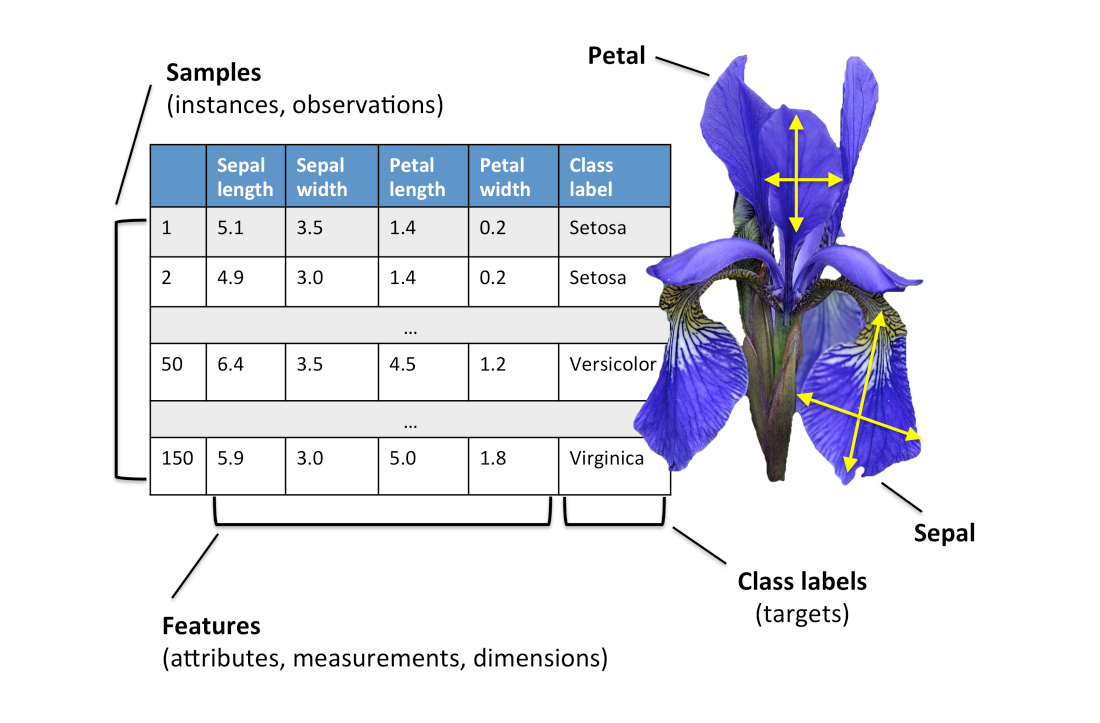

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset (flower classification)
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a classifier
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X_train, y_train)

# Make predictions
predictions = classifier.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, predictions)
print(f"Classification Accuracy: {accuracy:.2%}")
print(f"Predicted classes: {predictions[:5]}")
print(f"Actual classes: {y_test[:5]}")

Classification Accuracy: 100.00%
Predicted classes: [1 0 2 1 1]
Actual classes: [1 0 2 1 1]


### Example 2: Regression with Boston Housing Dataset

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load California housing dataset
housing = fetch_california_housing()
X, y = housing.data[:500], housing.target[:500]  # Use subset for speed

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions
predictions = regressor.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"\nFirst 5 predictions: {predictions[:5]}")
print(f"First 5 actual values: {y_test[:5]}")

Mean Squared Error: 0.21
R² Score: 0.81

First 5 predictions: [2.52559351 0.97113716 1.45014085 3.19893231 1.90248745]
First 5 actual values: [2.5   0.675 1.22  4.103 3.357]


## Understanding Features in Machine Learning

### What are Features?

**Features** are measurable properties or characteristics of your data that you use as input for machine learning algorithms. Think of them as columns in a spreadsheet.

**Example**: If you're predicting house prices:
- Features might include: square footage, number of bedrooms, location, age of house
- Target/Label: the price (what you want to predict)


In [3]:
# Example feature representation
house_data = {
    'square_feet': [1500, 2000, 1200, 1800],
    'bedrooms': [3, 4, 2, 3],
    'age_years': [10, 5, 15, 8],
    'price': [300000, 450000, 250000, 380000]  # This is the target
}

### Why CSV Format?

CSV (Comma-Separated Values) is one of the most common formats for ML datasets because:

1. **Structured**: Data is organized in rows and columns (tabular format)
2. **Easy to read**: Both humans and machines can parse it easily
3. **Universal**: Works with all ML libraries (scikit-learn, pandas, TensorFlow, etc.)

**CSV Structure:**
```
feature1,feature2,feature3,target
1.2,3.4,5.6,0
2.3,4.5,6.7,1
3.4,5.6,7.8,0
```

Each row = one sample/observation
Each column = one feature
Last column = target/label (what we want to predict)

### Converting Raw Data to Features

In [4]:
import pandas as pd
import numpy as np

# Example: Text data → Features
texts = ["I love this!", "Terrible product", "Amazing quality"]

# Feature extraction (simple bag-of-words approach)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
text_features = vectorizer.fit_transform(texts)

print("Text features as array:")
print(text_features.toarray())
print("\nFeature names (vocabulary):")
print(vectorizer.get_feature_names_out())

# Convert to CSV-like format (DataFrame)
df = pd.DataFrame(text_features.toarray(),
                  columns=vectorizer.get_feature_names_out())
print("\nAs DataFrame (CSV-like structure):")
print(df)

Text features as array:
[[0 1 0 0 0 1]
 [0 0 1 0 1 0]
 [1 0 0 1 0 0]]

Feature names (vocabulary):
['amazing' 'love' 'product' 'quality' 'terrible' 'this']

As DataFrame (CSV-like structure):
   amazing  love  product  quality  terrible  this
0        0     1        0        0         0     1
1        0     0        1        0         1     0
2        1     0        0        1         0     0


### Real Example: Iris Dataset as CSV

In [5]:
from sklearn.datasets import load_iris
import pandas as pd

# Load iris dataset
iris = load_iris()

# Create DataFrame (like a CSV)
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target

print("Iris dataset in CSV-like format:")
print(df_iris.head())

# Save as actual CSV
df_iris.to_csv('iris_dataset.csv', index=False)
print("\n✓ Saved as iris_dataset.csv")

Iris dataset in CSV-like format:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

✓ Saved as iris_dataset.csv


In [6]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [7]:
import wikipedia

topic1 = "Giraffe"
topic2 = "Elephant"


def get_wikipedia_content(topic, lang="en"):
    """Safely fetch Wikipedia content with error handling."""

    wikipedia.set_lang(lang)

    try:
        # Try to get the exact page
        page = wikipedia.page(topic, auto_suggest=False)
        return page.content

    except wikipedia.exceptions.DisambiguationError as e:
        # If multiple pages are found, use the first option
        print(f"Disambiguation for '{topic}': using '{e.options[0]}'")

        try:
            page = wikipedia.page(e.options[0], auto_suggest=False)
            return page.content
        except Exception as error:
            print(f"Error fetching '{e.options[0]}': {error}")
            return ""

    except wikipedia.exceptions.PageError:
        # Try again with auto-suggestion
        print(f"Page not found for '{topic}', trying auto-suggest...")

        try:
            page = wikipedia.page(topic, auto_suggest=True)
            return page.content
        except Exception as error:
            print(f"Could not fetch '{topic}': {error}")
            return ""

    except Exception as error:
        # Handle any unexpected error
        print(f"Unexpected error for '{topic}': {error}")
        return ""


# Fetch Wikipedia content
eng1 = get_wikipedia_content(topic1, "en")
eng2 = get_wikipedia_content(topic2, "en")

fr1 = get_wikipedia_content(topic1, "fr")
fr2 = get_wikipedia_content(topic2, "fr")


# Display results
print("\n✓ Successfully fetched Wikipedia pages")

print(f"English {topic1} length: {len(eng1)} characters")
print(f"English {topic2} length: {len(eng2)} characters")
print(f"French {topic1} length: {len(fr1)} characters")
print(f"French {topic2} length: {len(fr2)} characters")

Unexpected error for 'Giraffe': Expecting value: line 1 column 1 (char 0)
Unexpected error for 'Elephant': Expecting value: line 1 column 1 (char 0)

✓ Successfully fetched Wikipedia pages
English Giraffe length: 40485 characters
English Elephant length: 55952 characters
French Giraffe length: 0 characters
French Elephant length: 0 characters


This is what the text looks like:

In [8]:
eng2

'Elephants are the largest living land animals. Three living species are currently recognised: the African bush elephant (Loxodonta africana), the African forest elephant (L. cyclotis), and the Asian elephant (Elephas maximus). They are the only surviving members of the family Elephantidae and the order Proboscidea; extinct relatives include mammoths and mastodons. Distinctive features of elephants include a long proboscis called a trunk, tusks, large ear flaps, pillar-like legs, and tough but sensitive grey skin. The trunk is prehensile, bringing food and water to the mouth and grasping objects. Tusks, which are derived from the incisor teeth, serve both as weapons and as tools for moving objects and digging. The large ear flaps assist in maintaining a constant body temperature as well as in communication. African elephants have larger ears and concave backs, whereas Asian elephants have smaller ears and convex or level backs.\nElephants are scattered throughout sub-Saharan Africa, So

In [9]:
fr2

''

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [10]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [11]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [12]:
print(eng1)

...


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

# N-Grams: Explanation with Examples

## What are N-grams?
N-grams are continuous sequences of 'n' characters extracted from text. They convert text into numerical features for machine learning.

---

## Types of N-grams

### 1. UNIGRAM (n=1) - Single Character
**Example:** Word `"DATA"`

Unigrams: `D`, `A`, `T`, `A`

**Frequency:**
- D → 1
- A → 2  
- T → 1

---

### 2. BIGRAM (n=2) - Pairs of Characters
**Example:** Word `"MACHINE"`

Bigrams (sliding window): `MA`, `AC`, `CH`, `HI`, `IN`, `NE`

**Frequency:** Each → 1

---

### 3. TRIGRAM (n=3) - Three Characters
**Example:** Word `"LEARNING"`

Trigrams: `LEA`, `EAR`, `ARN`, `RNI`, `NIN`, `ING`

**Frequency:** Each → 1

---

## Why N-grams Matter in ML?

1. **Feature Extraction** - Convert text to numbers
2. **Pattern Recognition** - Capture language structure  
3. **Language Detection** - Identify languages automatically
4. **Text Classification** - Spam detection, sentiment analysis

---

## Summary
N-grams transform variable-length text into fixed numerical features, enabling machine learning algorithms to process and learn from text data.

In [13]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and French pages. Can you spot a difference?

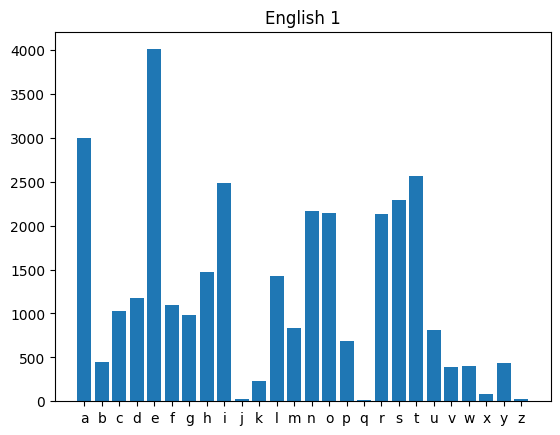

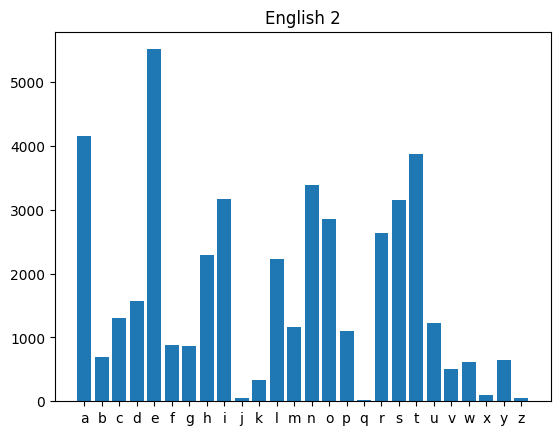

In [14]:
unigram_eng1 = Counter(ngrams(eng1,1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()
unigram_eng2 = Counter(ngrams(eng2,1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

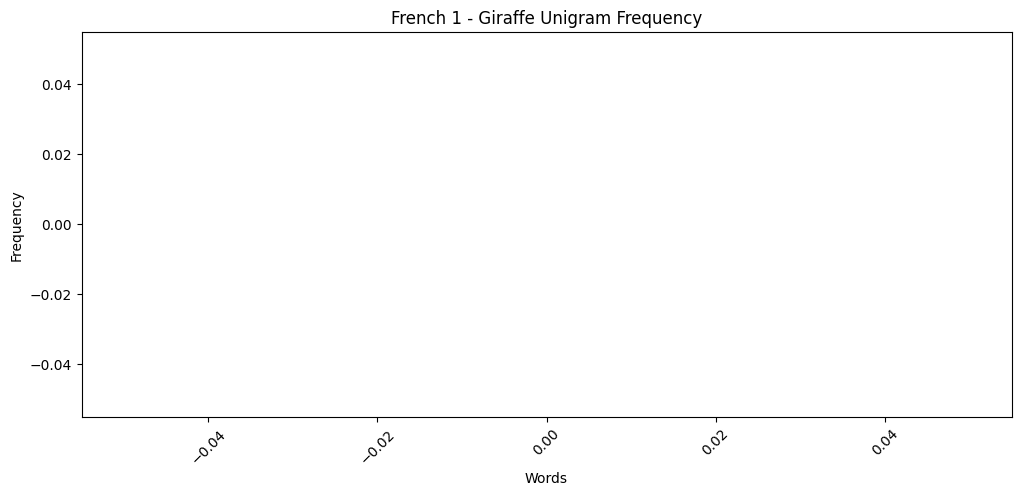

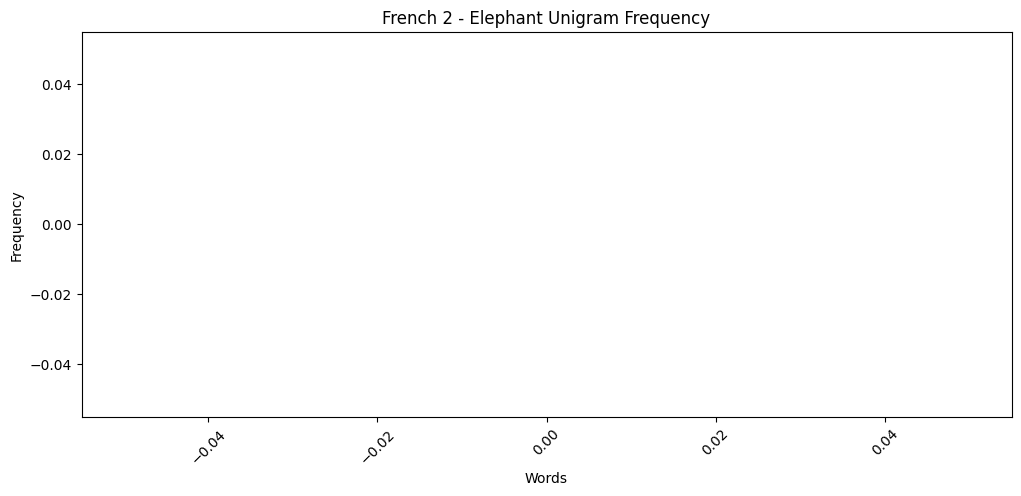

In [15]:
from collections import Counter
from nltk import ngrams
import matplotlib.pyplot as plt

# Convert French text into words
tokens_fr1 = fr1.split()
tokens_fr2 = fr2.split()

# Create unigrams
unigram_fr1 = Counter(ngrams(tokens_fr1, 1))
unigram_fr2 = Counter(ngrams(tokens_fr2, 1))

# Plot French Giraffe unigrams
words_fr1 = [" ".join(word) for word, count in unigram_fr1.most_common(20)]
counts_fr1 = [count for word, count in unigram_fr1.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words_fr1, counts_fr1)
plt.xticks(rotation=45)
plt.title("French 1 - Giraffe Unigram Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


# Plot French Elephant unigrams
words_fr2 = [" ".join(word) for word, count in unigram_fr2.most_common(20)]
counts_fr2 = [count for word, count in unigram_fr2.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words_fr2, counts_fr2)
plt.xticks(rotation=45)
plt.title("French 2 - Elephant Unigram Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

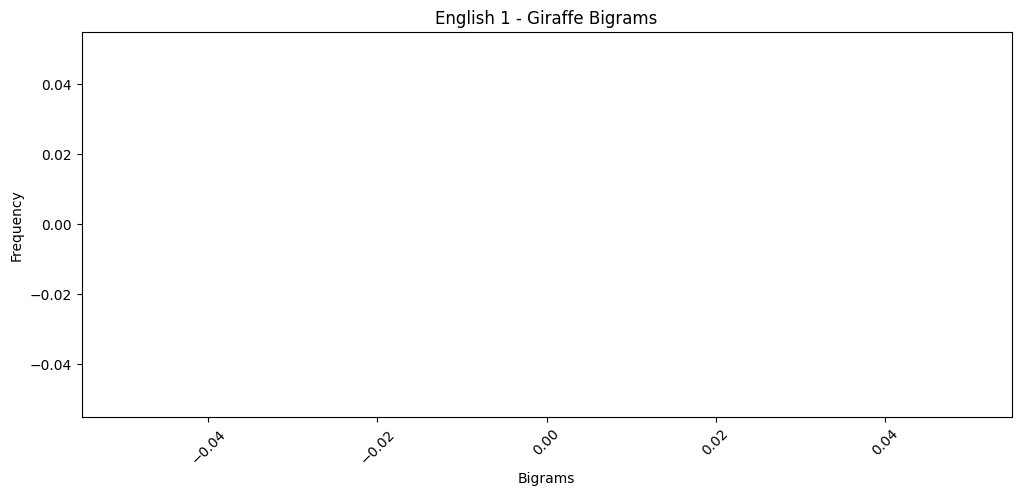

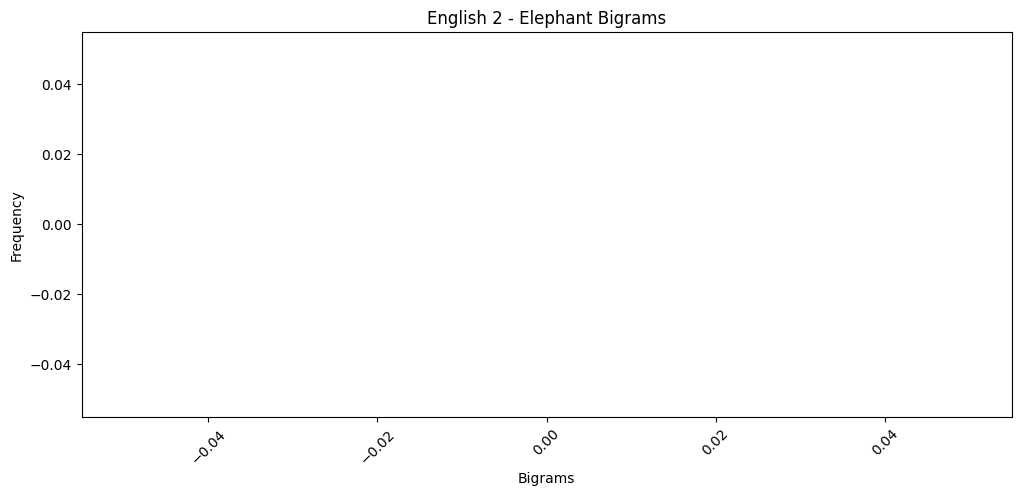

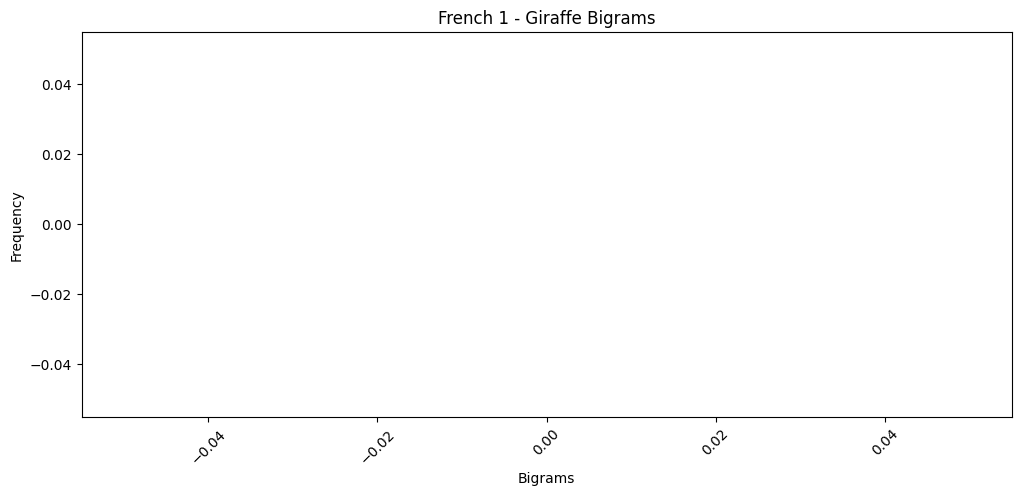

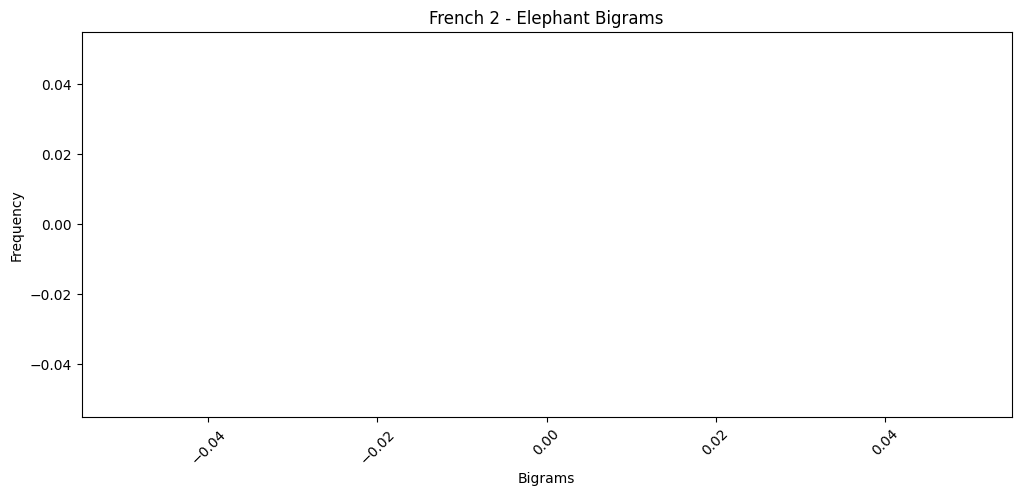

In [17]:
from collections import Counter
from nltk import ngrams
import matplotlib.pyplot as plt


# Tokenize the text
tokens_eng1 = eng1.split()
tokens_eng2 = eng2.split()
tokens_fr1 = fr1.split()
tokens_fr2 = fr2.split()


# ---------------- English 1 ----------------
bigram_eng1 = Counter(ngrams(tokens_eng1, 2))

words = [" ".join(bigram) for bigram, count in bigram_eng1.most_common(20)]
counts = [count for bigram, count in bigram_eng1.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("English 1 - Giraffe Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.show()


# ---------------- English 2 ----------------
bigram_eng2 = Counter(ngrams(tokens_eng2, 2))

words = [" ".join(bigram) for bigram, count in bigram_eng2.most_common(20)]
counts = [count for bigram, count in bigram_eng2.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("English 2 - Elephant Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.show()


# ---------------- French 1 ----------------
bigram_fr1 = Counter(ngrams(tokens_fr1, 2))

words = [" ".join(bigram) for bigram, count in bigram_fr1.most_common(20)]
counts = [count for bigram, count in bigram_fr1.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("French 1 - Giraffe Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.show()


# ---------------- French 2 ----------------
bigram_fr2 = Counter(ngrams(tokens_fr2, 2))

words = [" ".join(bigram) for bigram, count in bigram_fr2.most_common(20)]
counts = [count for bigram, count in bigram_fr2.most_common(20)]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("French 2 - Elephant Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def plotbihistogram(ngram):

    freq = np.zeros((26, 26))

    for ii in range(26):
        for jj in range(26):

            first = chr(ord('a') + ii)
            second = chr(ord('a') + jj)

            freq[ii, jj] = ngram.get((first, second), 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(freq, cmap='jet')

    plt.xticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))
    plt.yticks(range(26), list('abcdefghijklmnopqrstuvwxyz'))

    plt.xlabel("Second Letter")
    plt.ylabel("First Letter")
    plt.title("Bigram Frequency Heatmap")

    plt.colorbar(label="Frequency")

    plt.show()

    return freq

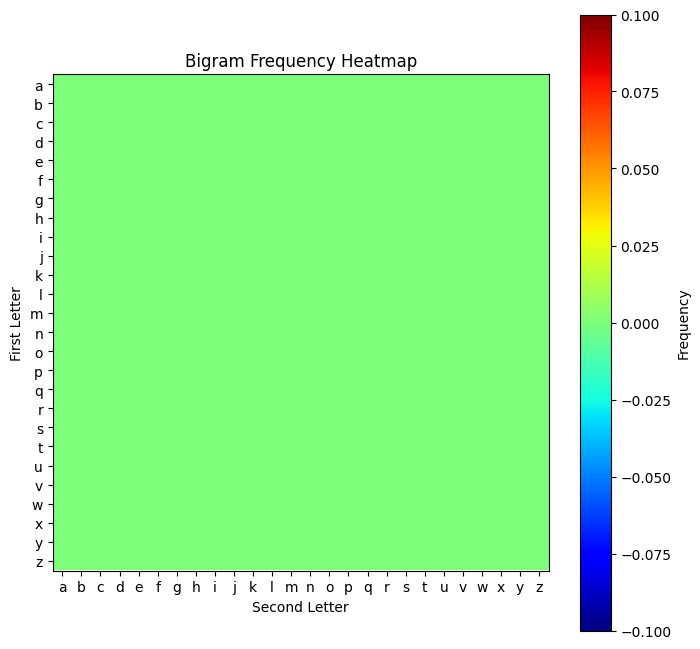

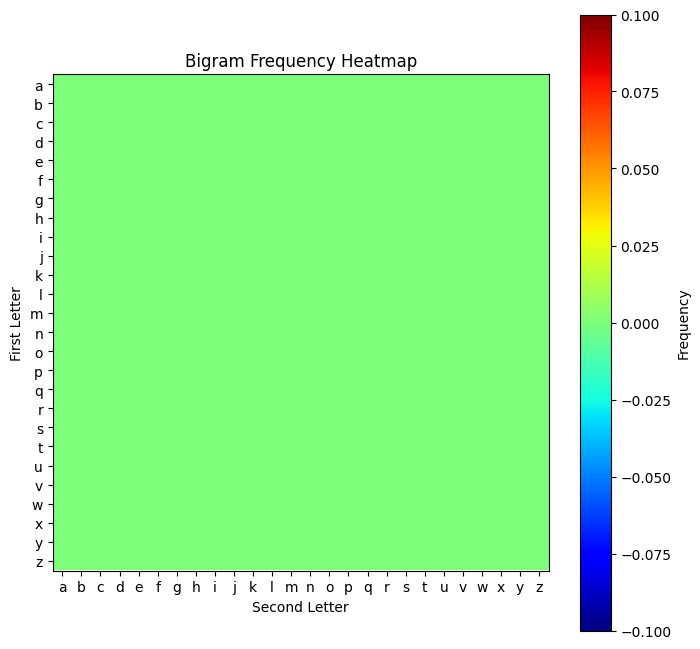

In [19]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()
bieng2 = plotbihistogram(bigram_eng2)

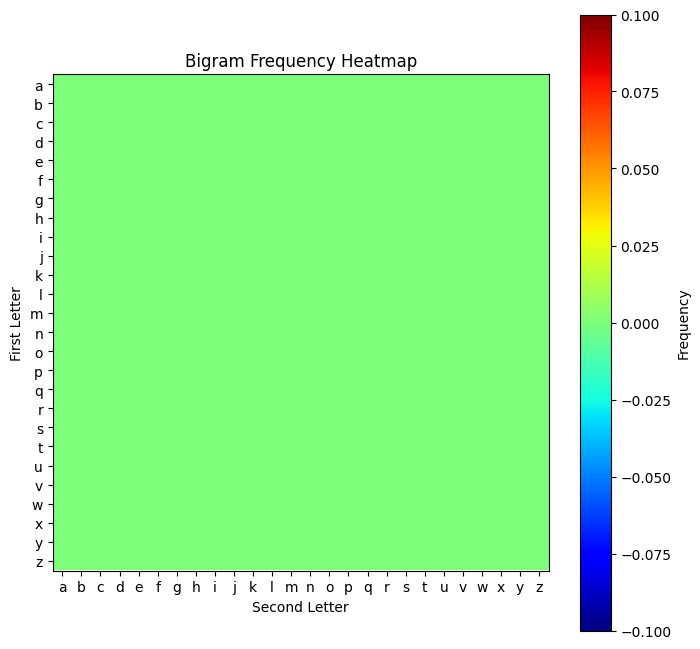

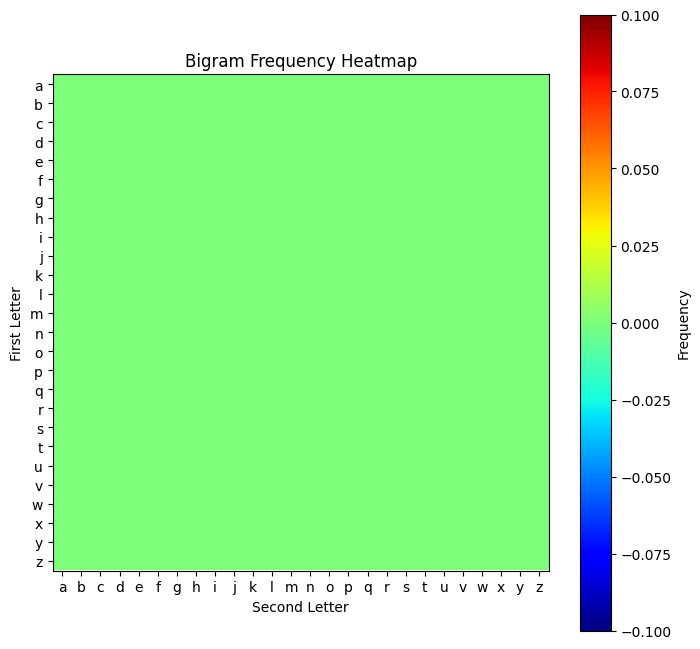

In [20]:
bifr1 = plotbihistogram(bigram_fr1)
plt.show()
bifr2 = plotbihistogram(bigram_fr2)

Let us look at the top 10 ngrams for each text.

In [21]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [22]:
print('\nEnglish 1:')
ShowTopN(bieng1)
print('\nEnglish 2:')
ShowTopN(bieng2)
print('\nFrench 1:')
ShowTopN(bifr1)
print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('z', 'v') : 0.0
('z', 'u') : 0.0
('z', 't') : 0.0
('z', 's') : 0.0
('z', 'r') : 0.0
('z', 'q') : 0.0
('z', 'p') : 0.0
('z', 'o') : 0.0
('z', 'n') : 0.0
('z', 'm') : 0.0

English 2:
('z', 'v') : 0.0
('z', 'u') : 0.0
('z', 't') : 0.0
('z', 's') : 0.0
('z', 'r') : 0.0
('z', 'q') : 0.0
('z', 'p') : 0.0
('z', 'o') : 0.0
('z', 'n') : 0.0
('z', 'm') : 0.0

French 1:
('z', 'v') : 0.0
('z', 'u') : 0.0
('z', 't') : 0.0
('z', 's') : 0.0
('z', 'r') : 0.0
('z', 'q') : 0.0
('z', 'p') : 0.0
('z', 'o') : 0.0
('z', 'n') : 0.0
('z', 'm') : 0.0

French 2:
('z', 'v') : 0.0
('z', 'u') : 0.0
('z', 't') : 0.0
('z', 's') : 0.0
('z', 'r') : 0.0
('z', 'q') : 0.0
('z', 'p') : 0.0
('z', 'o') : 0.0
('z', 'n') : 0.0
('z', 'm') : 0.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [23]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Extract a subset of the data for our experiment:

In [24]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

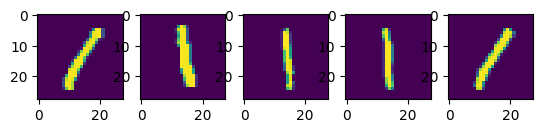

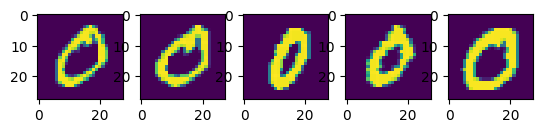

In [25]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no1[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no0[ii,:,:])
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

For each digit "1" image: Count how many pixels are NOT black
For each digit "0" image: Count how many pixels are NOT black

In [26]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

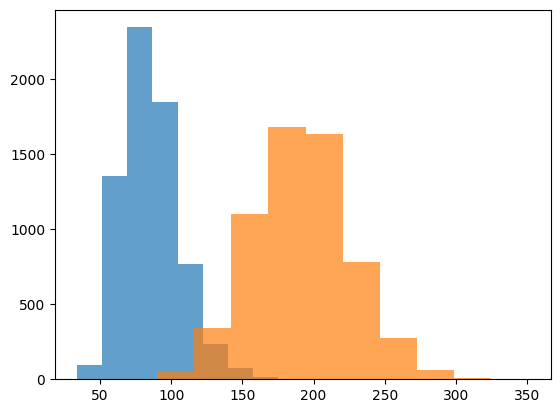

In [27]:
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [28]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

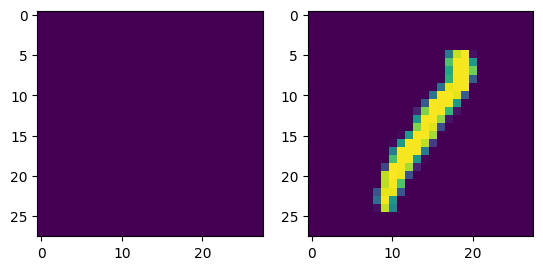

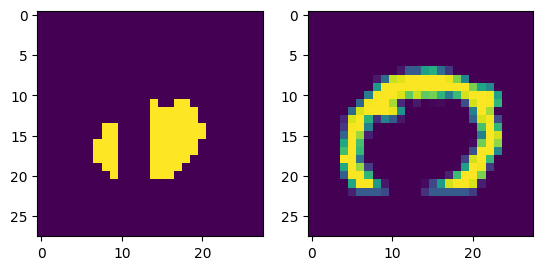

In [29]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

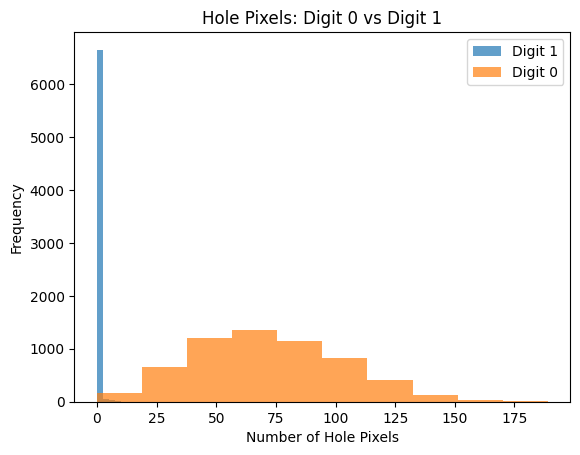

In [30]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.7, label='Digit 1');
plt.hist(hole0, alpha=0.7, label='Digit 0');
plt.legend()  # ← Adds legend box
plt.xlabel('Number of Hole Pixels')
plt.ylabel('Frequency')
plt.title('Hole Pixels: Digit 0 vs Digit 1')
plt.show()

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [31]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

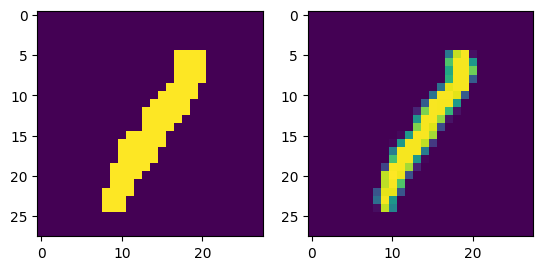

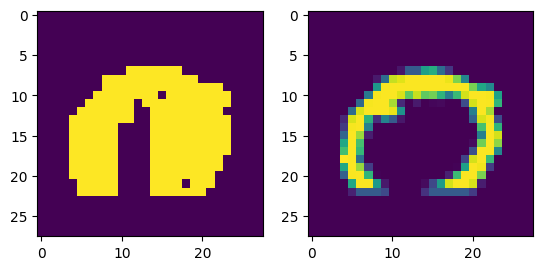

In [32]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

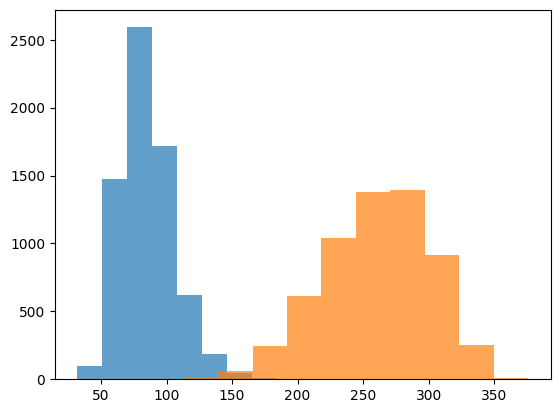

In [33]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.7);
plt.hist(hull0, alpha=0.7);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [34]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

Takes a digit image and fills in any empty spaces inside it, like coloring inside the lines completely.

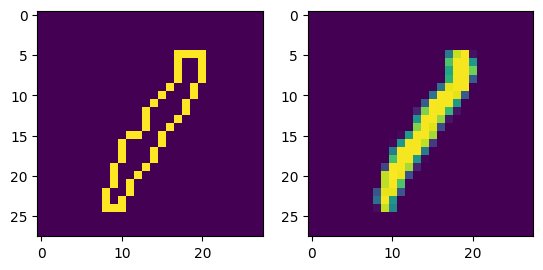

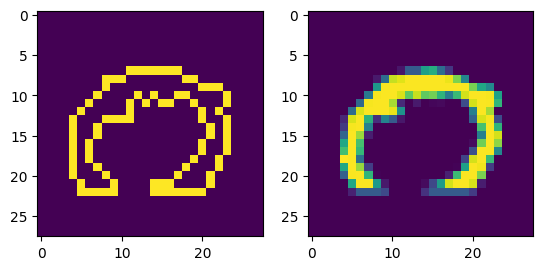

In [35]:
imgs = [no1[456,:,:],  no0[456,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

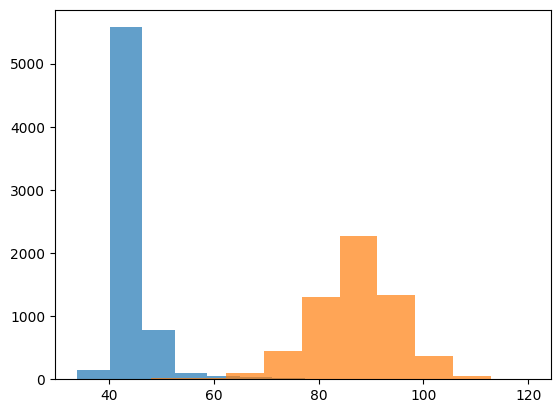

In [43]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.7);
plt.hist(bound0, alpha=0.7);

What will happen if we plot two features together?

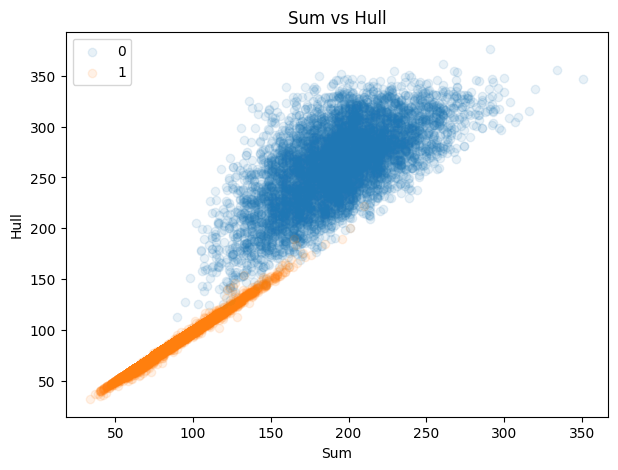

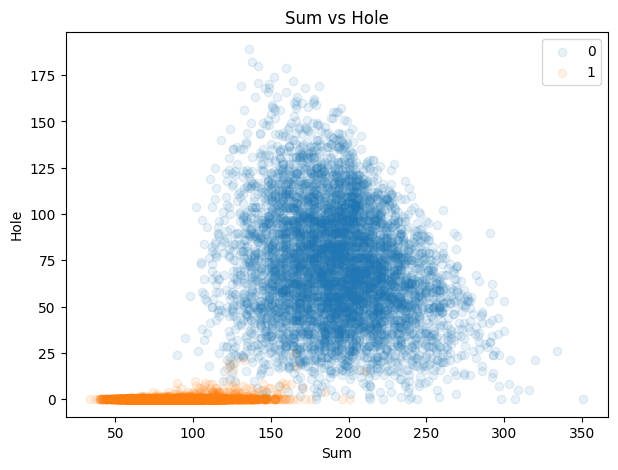

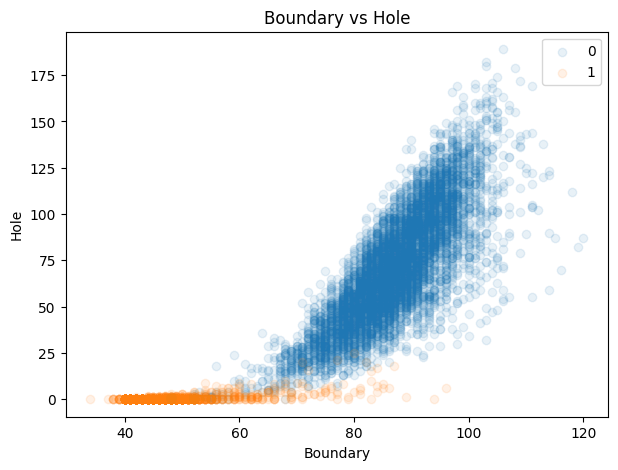

In [44]:
import matplotlib.pyplot as plt

# Sum vs Hull
plt.figure(figsize=(7, 5))
plt.scatter(sum0, hull0, alpha=0.1, label="0")
plt.scatter(sum1, hull1, alpha=0.1, label="1")

plt.xlabel("Sum")
plt.ylabel("Hull")
plt.title("Sum vs Hull")
plt.legend()
plt.show()


# Sum vs Hole
plt.figure(figsize=(7, 5))
plt.scatter(sum0, hole0, alpha=0.1, label="0")
plt.scatter(sum1, hole1, alpha=0.1, label="1")

plt.xlabel("Sum")
plt.ylabel("Hole")
plt.title("Sum vs Hole")
plt.legend()
plt.show()


# Boundary vs Hole
plt.figure(figsize=(7, 5))
plt.scatter(bound0, hole0, alpha=0.1, label="0")
plt.scatter(bound1, hole1, alpha=0.1, label="1")

plt.xlabel("Boundary")
plt.ylabel("Hole")
plt.title("Boundary vs Hole")
plt.legend()
plt.show()

Now let us try plotting 3 features together.

In [45]:
cl1 = ['class 1']*len(sum1)
cl0 = ['class 0']*len(sum0)
df = pd.DataFrame(list(zip(np.concatenate((hole0, hole0)), np.concatenate((sum1,sum0)),
                           np.concatenate((bound1,bound0)), np.concatenate((cl1, cl0)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?